In [1]:
from pathlib import Path
import subprocess

REPO_URL = "https://github.com/seoultechpse/fenicsx-colab.git"
ROOT = Path("/content")
REPO_DIR = ROOT / "fenicsx-colab"

subprocess.run(["git", "clone", REPO_URL, str(REPO_DIR)], check=True)

USE_COMPLEX = False  # <--- Set True ONLY if you need complex PETSc
USE_CLEAN = False    # <--- Set True to remove existing environment

opts_str = " ".join(
  [o for c, o in [(USE_COMPLEX, "--complex"), (USE_CLEAN, "--clean")] if c]
)

get_ipython().run_line_magic("run", f"{REPO_DIR / 'setup_fenicsx.py'} {opts_str}")

🔧 FEniCSx Setup Configuration
PETSc type      : real
Clean install   : False

⚠️  Google Drive not mounted — using local cache (/content)

🔧 Installing FEniCSx environment...

🔍 Verifying PETSc type...
✅ Installed: Real PETSc (float64)

✨ Loading FEniCSx Jupyter magic... %%fenicsx registered

✅ FEniCSx setup complete!

Next steps:
  1. Run %%fenicsx --info to verify installation
  2. Use %%fenicsx in cells to run FEniCSx code
  3. Use -np N for parallel execution (e.g., %%fenicsx -np 4)

📌 Note: Real PETSc is installed
   - Recommended for most FEM problems
   - For complex problems, reinstall with --complex


---

# Integration over Sub-domains in FEniCSx

This notebook demonstrates subdomain integration techniques in FEniCSx.

**Topics:**
- MeshTags for subdomain marking
- Custom integration measures
- One-sided interior integrals
- Visualization of subdomains

In [2]:
%%fenicsx

# Complete example in a single cell

# ============================================================================
# SETUP AND IMPORTS
# ============================================================================
from mpi4py import MPI
import numpy as np
import dolfinx
import dolfinx.fem
import dolfinx.mesh
import ufl
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

print(f"DOLFINx version: {dolfinx.__version__}")
print("="*70)

# ============================================================================
# 1. CREATE MESH AND DEFINE SUBDOMAINS
# ============================================================================
print("\n1. Creating mesh with subdomains...")

mesh = dolfinx.mesh.create_unit_square(
    MPI.COMM_WORLD, 10, 10,
    dolfinx.mesh.CellType.triangle,
    ghost_mode=dolfinx.mesh.GhostMode.shared_facet,
)

# Define inner square region: [0.3, 0.8] x [0.4, 0.6]
def inner_square(x, tol=1e-13):
    return (
        (0.3 - tol <= x[0]) & (x[0] <= 0.8 + tol) &
        (x[1] <= 0.6 + tol) & (0.4 - tol <= x[1])
    )

print(f"  - Mesh: {mesh.topology.index_map(2).size_local} cells")
print(f"  - Inner region: 0.3 ≤ x ≤ 0.8, 0.4 ≤ y ≤ 0.6")

# ============================================================================
# 2. MARK CELLS WITH MESHTAGS
# ============================================================================
print("\n2. Marking cells...")

tdim = mesh.topology.dim
cell_map = mesh.topology.index_map(tdim)
num_cells = cell_map.size_local + cell_map.num_ghosts

# Initialize all cells with marker 1 (outer region)
marker = np.ones(num_cells, dtype=np.int32)

# Find and mark inner cells with 2
inner_cells = dolfinx.mesh.locate_entities(mesh, tdim, inner_square)
marker[inner_cells] = 2

print(f"  - Outer region cells (marker=1): {np.sum(marker == 1)}")
print(f"  - Inner region cells (marker=2): {np.sum(marker == 2)}")

# Create MeshTags object
cell_tag = dolfinx.mesh.meshtags(
    mesh, tdim,
    np.arange(num_cells, dtype=np.int32),
    marker
)

print("  ✓ MeshTags created")

# ============================================================================
# 3. CREATE INTEGRATION MEASURES
# ============================================================================
print("\n3. Creating integration measures...")

dx = ufl.Measure("dx", domain=mesh, subdomain_data=cell_tag)

print("  ✓ Custom measure dx created with subdomain data")

# ============================================================================
# 4. VERIFY SUBDOMAIN INTEGRATION
# ============================================================================
print("\n4. Verifying subdomain integration...")

# Total volume (should be 1.0)
total_vol = dolfinx.fem.assemble_scalar(
    dolfinx.fem.form(1 * ufl.dx(domain=mesh))
)
print(f"  - Total volume: {total_vol:.6f}")

# Inner region volume (should be 0.5 * 0.2 = 0.1)
inner_vol = dolfinx.fem.assemble_scalar(
    dolfinx.fem.form(1 * dx(2))
)
print(f"  - Inner volume: {inner_vol:.6f} (expected: 0.1)")

# Outer region volume (should be 0.9)
outer_vol = dolfinx.fem.assemble_scalar(
    dolfinx.fem.form(1 * dx(1))
)
print(f"  - Outer volume: {outer_vol:.6f} (expected: 0.9)")

# Sum should equal total
print(f"  - Sum check: {inner_vol + outer_vol:.6f} (should be 1.0)")

# ============================================================================
# 5. INTEGRATE DIFFERENT EXPRESSIONS OVER REGIONS
# ============================================================================
print("\n5. Integrating expressions over regions...")

x = ufl.SpatialCoordinate(mesh)

# Integrate x over inner region
inner_x_integral = dolfinx.fem.assemble_scalar(
    dolfinx.fem.form(x[0] * dx(2))
)
print(f"  - ∫(x dx) over inner: {inner_x_integral:.6f}")

# Integrate y over outer region
outer_y_integral = dolfinx.fem.assemble_scalar(
    dolfinx.fem.form(x[1] * dx(1))
)
print(f"  - ∫(y dx) over outer: {outer_y_integral:.6f}")

# ============================================================================
# 6. VISUALIZE SUBDOMAINS
# ============================================================================
print("\n6. Creating visualization...")

fig, ax = plt.subplots(figsize=(8, 8))

# Plot mesh cells colored by marker
cells_geom = mesh.geometry.x
connectivity = mesh.geometry.dofmap

for cell in range(cell_map.size_local):
    vertices = connectivity[cell]
    coords = cells_geom[vertices]

    # Close the triangle
    poly_coords = np.vstack([coords, coords[0]])

    color = 'lightblue' if marker[cell] == 1 else 'salmon'
    ax.fill(poly_coords[:, 0], poly_coords[:, 1],
            color=color, edgecolor='black', linewidth=0.5, alpha=0.6)

# Add rectangle outline for inner region
rect = Rectangle((0.3, 0.4), 0.5, 0.2,
                 linewidth=2, edgecolor='red',
                 facecolor='none', linestyle='--')
ax.add_patch(rect)

ax.set_xlim([0, 1])
ax.set_ylim([0, 1])
ax.set_aspect('equal')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Subdomain Markers\n(Blue=Outer, Red=Inner)')
ax.grid(True, alpha=0.3)

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='lightblue', edgecolor='black', label='Outer (marker=1)'),
    Patch(facecolor='salmon', edgecolor='black', label='Inner (marker=2)')
]
ax.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.savefig('subdomain_markers.png', dpi=150, bbox_inches='tight')
print("  ✓ Saved: subdomain_markers.png")
plt.close()

# ============================================================================
# 7. CUSTOM INTEGRATION ENTITIES (ONE-SIDED INTEGRALS)
# ============================================================================
print("\n7. Creating custom integration entities...")

# Find interior facets at x = 0.5
inner_facets = dolfinx.mesh.locate_entities(
    mesh, tdim - 1,
    lambda x: np.isclose(x[0], 0.5)
)
print(f"  - Found {len(inner_facets)} facets at x=0.5")

# Compute cell midpoints
midpoints = dolfinx.mesh.compute_midpoints(
    mesh, tdim, np.arange(num_cells, dtype=np.int32)
)

# Create connectivity
mesh.topology.create_connectivity(tdim - 1, tdim)
mesh.topology.create_connectivity(tdim, tdim - 1)
c_to_f = mesh.topology.connectivity(tdim, tdim - 1)
f_to_c = mesh.topology.connectivity(tdim - 1, tdim)

# Build integration entities (cell, local_facet) for left side
integration_entities = np.empty((len(inner_facets), 2), dtype=np.int32)

for i, facet in enumerate(inner_facets):
    cells = f_to_c.links(facet)
    if len(cells) != 2:
        continue  # Skip boundary facets

    # Find cell on left side (x < 0.5)
    for cell in cells:
        if midpoints[cell][0] < 0.5:
            # Find local facet index in this cell
            local_facets = c_to_f.links(cell)
            facet_idx = np.flatnonzero(local_facets == facet)
            if len(facet_idx) == 1:
                integration_entities[i] = (cell, facet_idx[0])
                break

print(f"  ✓ Created {len(integration_entities)} integration entities")
print(f"  - Format: (cell_index, local_facet_index)")
print(f"  - Sample: {integration_entities[0]}")

# ============================================================================
# 8. USE CUSTOM INTEGRATION ENTITIES
# ============================================================================
print("\n8. Using custom integration entities...")

# Create measure with custom entities
subdomain_data = [(7, integration_entities.flatten())]
ds = ufl.Measure("ds", subdomain_data=subdomain_data, domain=mesh)

# Verify by integrating against facet normal
expression = (x[0] + x[1]**2) * ufl.FacetNormal(mesh)
correct_normal = dolfinx.fem.Constant(mesh, dolfinx.default_scalar_type((1, 0)))

facet_integral = dolfinx.fem.form(
    ufl.inner(expression, correct_normal) * ds(7)
)

result = mesh.comm.allreduce(
    dolfinx.fem.assemble_scalar(facet_integral),
    op=MPI.SUM
)

print(f"  - One-sided integral result: {result:.6f}")
print("  - Analytical: ∫₀¹ (0.5 + y²) dy = 0.5 + 1/3 = 0.8333...")
print(f"  - Error: {abs(result - 5/6):.2e}")

# ============================================================================
# 9. VISUALIZE INTEGRATION ENTITIES
# ============================================================================
print("\n9. Visualizing integration entities...")

fig, ax = plt.subplots(figsize=(10, 8))

# Plot mesh
for cell in range(cell_map.size_local):
    vertices = connectivity[cell]
    coords = cells_geom[vertices]
    poly_coords = np.vstack([coords, coords[0]])
    ax.plot(poly_coords[:, 0], poly_coords[:, 1],
            'k-', linewidth=0.5, alpha=0.3)

# Highlight cells involved in integration
for cell_idx, local_facet in integration_entities:
    vertices = connectivity[cell_idx]
    coords = cells_geom[vertices]
    poly_coords = np.vstack([coords, coords[0]])
    ax.fill(poly_coords[:, 0], poly_coords[:, 1],
            color='yellow', alpha=0.3, edgecolor='orange', linewidth=2)

# Mark the x=0.5 line
ax.axvline(x=0.5, color='red', linewidth=2, linestyle='--',
           label='Integration line (x=0.5)')

ax.set_xlim([0, 1])
ax.set_ylim([0, 1])
ax.set_aspect('equal')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('One-Sided Integration Entities\n(Yellow cells on left of x=0.5)')
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.savefig('integration_entities.png', dpi=150, bbox_inches='tight')
print("  ✓ Saved: integration_entities.png")
plt.close()

# ============================================================================
# SUMMARY
# ============================================================================
print("\n" + "="*70)
print("SUMMARY")
print("="*70)
print("\n✓ Topics covered:")
print("  1. MeshTags creation and usage")
print("  2. Subdomain integration with custom measures")
print("  3. Volume verification")
print("  4. Expression integration over regions")
print("  5. Custom integration entities")
print("  6. One-sided interior integrals")
print("  7. Visualization of subdomains")
print("\n✓ Files generated:")
print("  - subdomain_markers.png")
print("  - integration_entities.png")
print("\n" + "="*70)
print("Example completed successfully!")
print("="*70)

DOLFINx version: 0.10.0

1. Creating mesh with subdomains...
  - Mesh: 200 cells
  - Inner region: 0.3 ≤ x ≤ 0.8, 0.4 ≤ y ≤ 0.6

2. Marking cells...
  - Outer region cells (marker=1): 180
  - Inner region cells (marker=2): 20
  ✓ MeshTags created

3. Creating integration measures...
  ✓ Custom measure dx created with subdomain data

4. Verifying subdomain integration...
  - Total volume: 1.000000
  - Inner volume: 0.100000 (expected: 0.1)
  - Outer volume: 0.900000 (expected: 0.9)
  - Sum check: 1.000000 (should be 1.0)

5. Integrating expressions over regions...
  - ∫(x dx) over inner: 0.055000
  - ∫(y dx) over outer: 0.450000

6. Creating visualization...
  ✓ Saved: subdomain_markers.png

7. Creating custom integration entities...
  - Found 10 facets at x=0.5
  ✓ Created 10 integration entities
  - Format: (cell_index, local_facet_index)
  - Sample: [30  0]

8. Using custom integration entities...
  - One-sided integral result: 0.833333
  - Analytical: ∫₀¹ (0.5 + y²) dy = 0.5 + 1/3 =

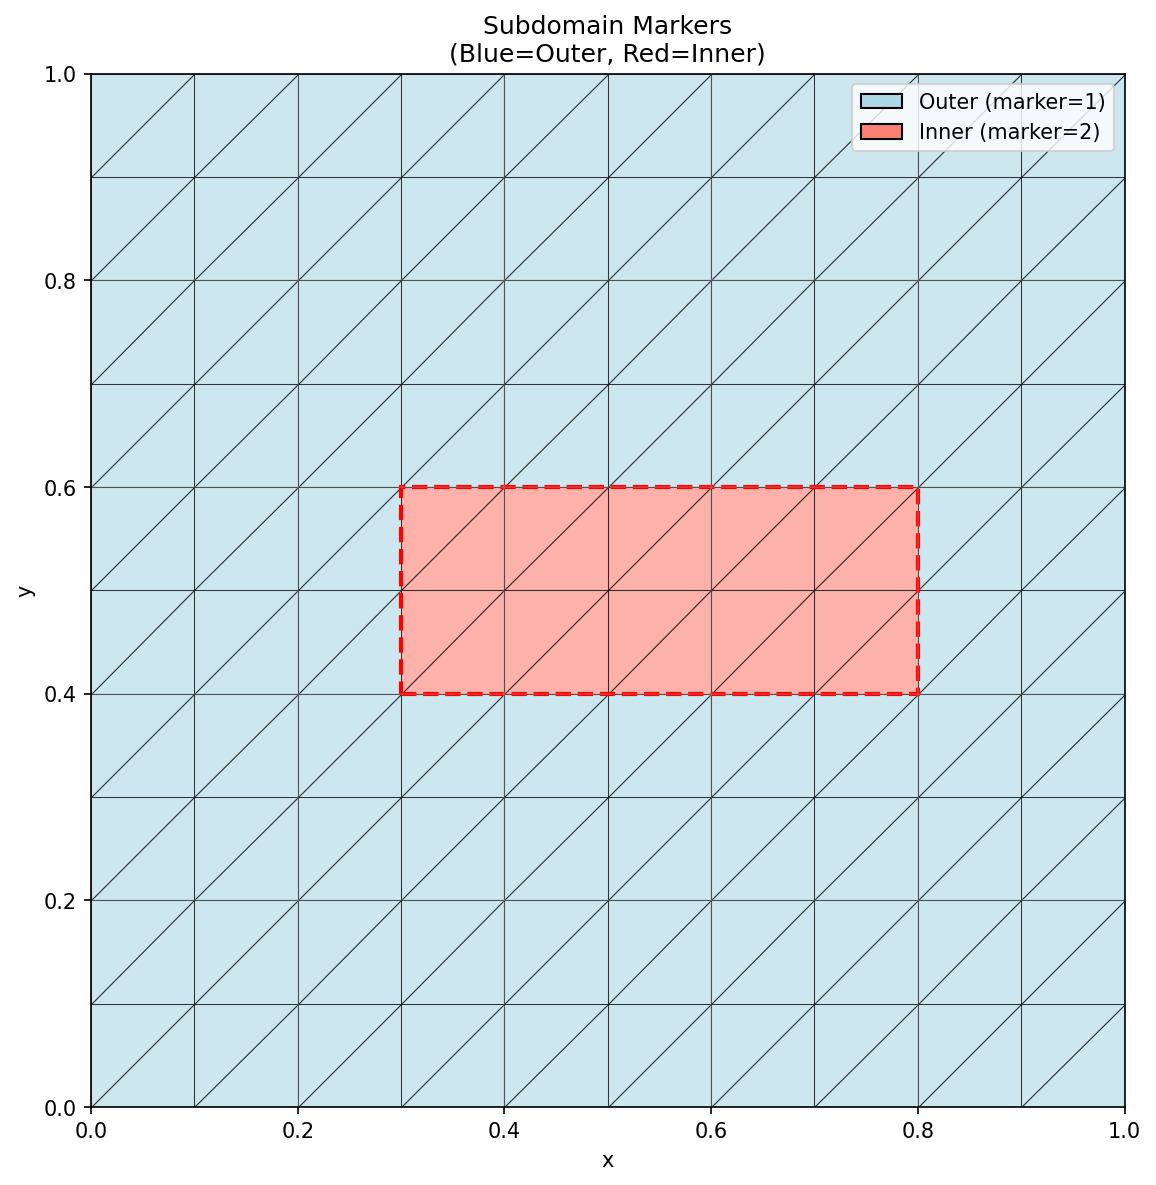

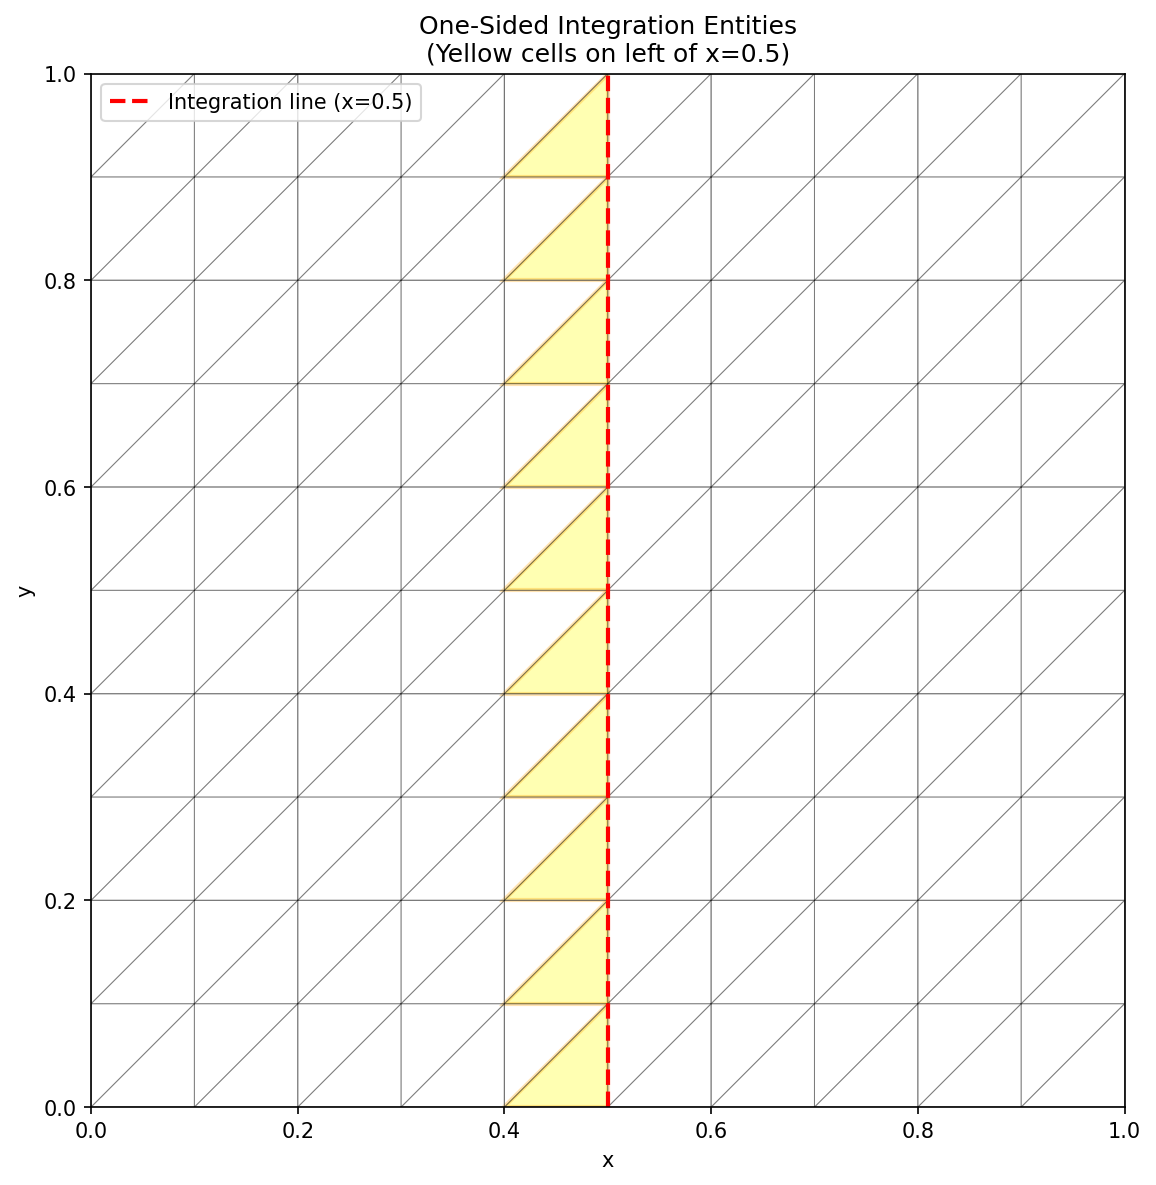

In [3]:
from IPython.display import Image, display, HTML

display(Image("subdomain_markers.png"))
display(Image("integration_entities.png"))